In [4]:
import os
os.chdir("..")
print(os.getcwd())

import json

import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import pandas as pd
from glob import glob
import numpy as np
from PIL import Image
from scipy.ndimage import gaussian_filter1d
from tqdm.auto import tqdm


plt.rc("font", size=14)

/data/chen


/home/chen/miniconda3/envs/DETECT/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
grad_dir = "/data/chen/detect/runs_/facial_small_gradient_confidence_drop_0318_1443/15_Eyeglasses"
random_dir = "/data/chen/detect/runs_/facial_small_random_confidence_drop_0318_1250/15_Eyeglasses"
occlusion_dir = "/data/chen/detect/runs_/facial_small_occlusion_confidence_drop_0318_1827/15_Eyeglasses"
smoothgrad_dir = "/data/chen/detect/runs_/facial_small_smoothgrad_confidence_drop_0318_1635/15_Eyeglasses"

### Check Confidence Shift

In [5]:
df = []

for cdir in [grad_dir, smoothgrad_dir, occlusion_dir, random_dir]:
    dfs = []

    for exp in tqdm(glob(cdir + "/*")):

        for data_file in glob(exp + "/*.json"):
            channel = data_file.split("/")[-1].split("_")[-1].split(".")[0]
            with open(data_file, "rb") as f:
                data = json.load(f)
            data["channel"] = channel

            dfs.append(pd.DataFrame([data]))
    df.append(pd.concat(dfs, ignore_index=True))


100%|██████████| 50/50 [00:02<00:00, 16.72it/s]

100%|██████████| 50/50 [00:02<00:00, 17.91it/s]

100%|██████████| 50/50 [00:02<00:00, 17.04it/s]

100%|██████████| 50/50 [00:02<00:00, 16.97it/s]


Mean: 0.369727450875675, std: 0.8291353181419715
Mean: 0.46988128960132597, std: 0.996768035284257
Mean: 0.0524730466113371, std: 0.3221977858337368
Mean: 0.04753526367159451, std: 0.3181854229539782
Runtime Stats:
Mean: 0.41725455732906563, std: 0.04688249247593728
Mean: 0.41699438184850357, std: 0.046583477089710806
Mean: 0.4169681667440078, std: 0.045617503769727355
Mean: 0.41932574185203103, std: 0.04560080238537079


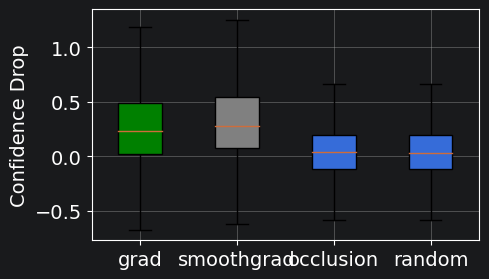

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
bplot = ax.boxplot(
    [d["confidence_drop"] for d in df],
    labels=[ "grad", "smoothgrad", "occlusion", "random"],
    patch_artist=True,
    showfliers=False,
)

for patch, color in zip(bplot["boxes"], ["green", "grey"]):
    patch.set_facecolor(color)

# ax.set_yscale("symlog", linthresh=1)
ax.set_ylabel("Confidence Drop")
ax.grid(zorder=0)
#plt.savefig("figures/RQ1/cdrop.pdf", bbox_inches="tight")
# matplot2tikz.save("figures/RQ1/cdrop.tex")
for d in [d["confidence_drop"] for d in df]:
    print(f"Mean: {d.mean()}, std: {d.std()}")

print("Runtime Stats:")
for d in [d["runtime"] for d in df]:
    print(f"Mean: {d.mean()}, std: {d.std()}")

### Check Runtime

In [8]:
import os
from datetime import datetime

data = []
for base_dir in [grad_dir, smoothgrad_dir, occlusion_dir, random_dir]:
    runt = []
    # Iterate through subfolders directly under the base_dir
    last_timestamp = None
    for i in range(50):
        subfolder_path = os.path.join(base_dir, f"{i}")
        # Get creation time and last modification time of the subfolder
        creation_timestamp = os.path.getctime(subfolder_path)
        if last_timestamp is not None:
            runtime_diff = (creation_timestamp - last_timestamp)/170 #  17 layer 10 channel per layer
            runt.append(runtime_diff)
        last_timestamp = creation_timestamp
    data.append(runt)
for d in data:
    print(f"mean: {np.mean(d):.3f}, std: {np.std(d):.3f}")


mean: 0.786, std: 0.038
mean: 0.789, std: 0.038
mean: 1.557, std: 0.039
mean: 0.797, std: 0.038


In [46]:
from sewar import msssim
import matplot2tikz

df = []

for cdir in [grad_dir, smoothgrad_dir, occlusion_dir]:
    dfs = []
    for exp in tqdm(glob(cdir + "/*")):
        original_image = Image.open(exp + "/1_original.png")
        original_image = np.array(original_image).astype(np.float32) / 255.0
        full = np.linalg.norm(np.ones_like(original_image))

        for data_file in glob(exp + "/*.json"):
            channel = data_file.split("/")[-1].split("_")[-1].split(".")[0]
            with open(data_file, "rb") as f:
                data = json.load(f)
            data["channel"] = channel
            data_image = Image.open(data["img_path"])
            data_image = np.array(data_image).astype(np.float32) / 255.0
            data["image_change"] = np.linalg.norm(original_image - data_image) / full
            data["ssim"] = msssim(
                original_image, data_image, MAX=1.0
            ).real  # This is very slow, exclude to run faster
            dfs.append(pd.DataFrame([data]))
    df.append(pd.concat(dfs, ignore_index=True))

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

Mean: 0.506531277888599, std: 1.2301998971454515
Mean: 0.5814810216108108, std: 1.2871555362891216
Mean: 0.06210376017871388, std: 0.3854690744914216


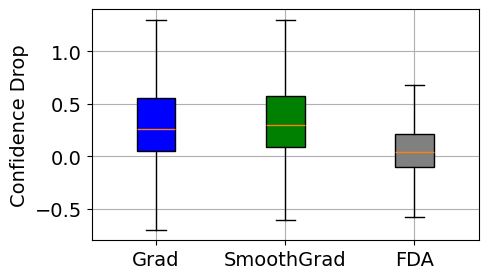

In [37]:

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
bplot = ax.boxplot(
    [d["confidence_drop"] for d in df],
    tick_labels=["Grad", "SmoothGrad", "FDA"],
    patch_artist=True,
    showfliers=False,
)

for patch, color in zip(bplot["boxes"], ["blue", "green", "grey"]):
    patch.set_facecolor(color)

# ax.set_yscale("symlog", linthresh=1)
ax.set_ylabel("Confidence Drop")
ax.grid(zorder=0)
plt.savefig("figures/RQ1/cdrop.pdf", bbox_inches="tight")
matplot2tikz.save("figures/RQ1/cdrop.tex")
for d in [d["confidence_drop"] for d in df]:
    print(f"Mean: {d.mean()}, std: {d.std()}")

/tmp/ipykernel_1646437/4003898891.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


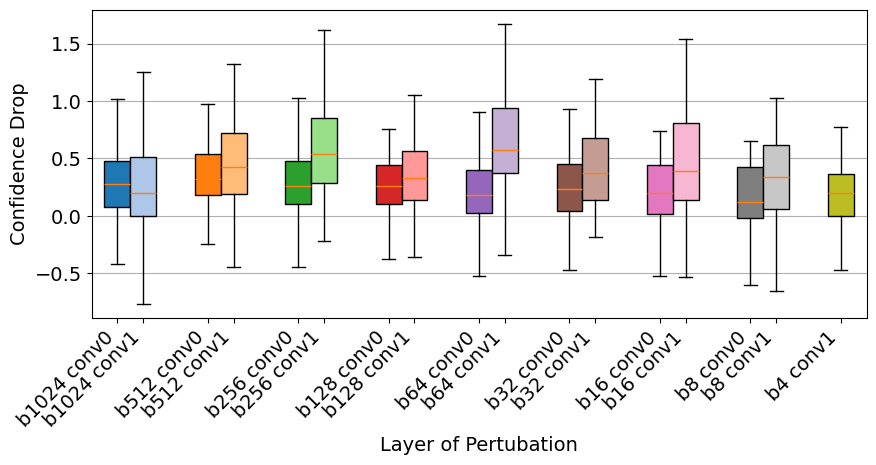

In [21]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 4),
)  # sharex=True, gridspec_kw={"height_ratios": [2.5, 5]}
boxps = []
ticks = []
for layer, grouped in df[1].groupby("layer_name"):
    boxps.append(grouped["confidence_drop"])
    ticks.append(" ".join(layer.split(".")[:2]))
# Here we sort based on layer-scale
boxps, ticks, _ = zip(
    *sorted(
        zip(boxps, ticks, [int(t.split(" ")[0][1:]) for t in ticks]),
        key=lambda x: x[2],
        reverse=True,
    )
)

positions = [0]
prev_tick = None
for i, tick in enumerate(ticks):
    if prev_tick is None:
        prev_tick = tick
    else:
        if prev_tick.split(" ")[0] == tick.split(" ")[0]:
            positions.append(positions[-1] + 0.5)
        else:
            positions.append(positions[-1] + 1.25)
        prev_tick = tick

bplot = ax.boxplot(
    boxps, positions=positions, tick_labels=ticks, patch_artist=True, showfliers=False
)

cmap = get_cmap("tab20")
for i, patch in enumerate(bplot["boxes"]):
    patch.set_facecolor(cmap(2 * (i // 2) + (i % 2)))

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
# ax.set_yscale("symlog", linthresh=1)
ax.set_xlabel("Layer of Pertubation")


# ax[0].boxplot(boxps, positions=positions, tick_labels=ticks, patch_artist=True)
# ax[0].set_ylim(1, None)
ax.grid(zorder=0, axis="y")
ax.set_ylabel("Confidence Drop")
# ax[0].set_ylabel("Confidence Drop > 1")
plt.subplots_adjust(hspace=0.05)
plt.savefig("figures/RQ1/layers_cdrop.pdf", bbox_inches="tight")

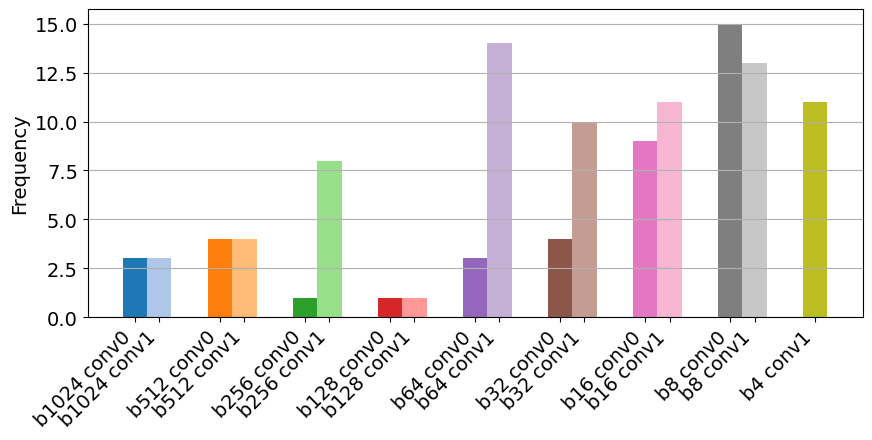

In [34]:
plt.show()
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 4),
)  # sharex=True,

bar_a, bar_t = [], []
ticks = []
for layer, grouped in df[1].groupby("layer_name"):
    bar_a.append(len(grouped["channel"].unique()))
    bar_t.append(len(grouped.loc[grouped["confidence_drop"] > 1, "channel"].unique()))
    ticks.append(" ".join(layer.split(".")[:2]))
# Here we sort based on layer-scale
bar_a, bar_t, ticks, _ = zip(
    *sorted(
        zip(bar_a, bar_t, ticks, [int(t.split(" ")[0][1:]) for t in ticks]),
        key=lambda x: x[3],
        reverse=True,
    )
)

positions = [0]
prev_tick = None
for i, tick in enumerate(ticks):
    if prev_tick is None:
        prev_tick = tick
    else:
        if prev_tick.split(" ")[0] == tick.split(" ")[0]:
            positions.append(positions[-1] + 0.5)
        else:
            positions.append(positions[-1] + 1.25)
        prev_tick = tick
colors = [cmap(2 * (i // 2) + (i % 2)) for i in range(len(ticks))]
ax.bar(positions, bar_t, color=colors, width=0.5)
# ax[1].bar(positions, bar_a, color=colors, width=0.5)


ax.set_xticks(positions)
ax.grid(zorder=0, axis="y")
ax.set_xticklabels(ticks, rotation=45, ha="right")

# ax[1].set_ylabel("Layers Used")
ax.set_ylabel("Frequency")
plt.subplots_adjust(hspace=0.05)
plt.savefig("figures/RQ1/layers_used.pdf", bbox_inches="tight")
matplot2tikz.save("figures/RQ1/layers_used.tex")

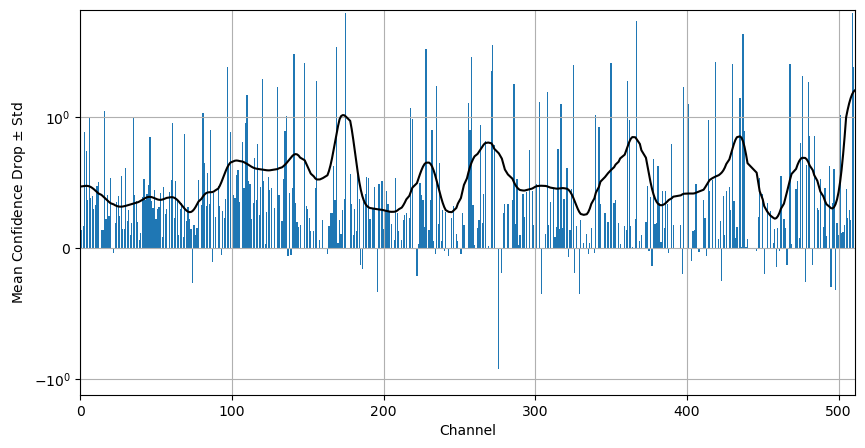

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
grouped = df[1].groupby("channel")["confidence_drop"].agg(["mean", "std"]).reset_index()
grouped["channel"] = grouped["channel"].astype(int)
grouped = grouped.sort_values("channel")
ax.bar(grouped["channel"], grouped["mean"])

smoothed = gaussian_filter1d(grouped["mean"], sigma=5)
ax.plot(grouped["channel"], smoothed, color="black")

ax.set_xlabel("Channel")
ax.set_ylabel(r"Mean Confidence Drop $\pm$ Std")
ax.set_xlim(0, grouped["channel"].max())
ax.set_yscale("symlog", linthresh=1)
ax.grid(zorder=0)
plt.savefig("figures/RQ1/ch_conf_impact.pdf", bbox_inches="tight")
# matplot2tikz.save("figures/RQ1/ch_conf_impact.tex")

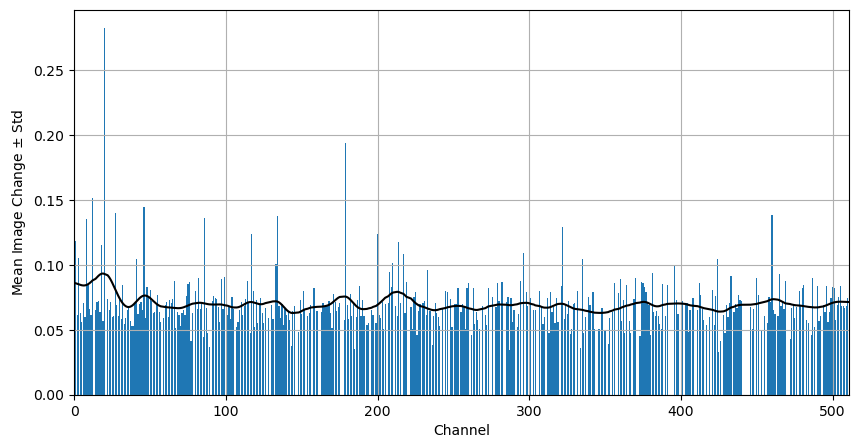

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
grouped = df[1].groupby("channel")["image_change"].agg(["mean", "std"]).reset_index()
grouped["channel"] = grouped["channel"].astype(int)
grouped = grouped.sort_values("channel")
ax.bar(grouped["channel"], grouped["mean"], capsize=3)

smoothed = gaussian_filter1d(grouped["mean"], sigma=5)
ax.plot(grouped["channel"], smoothed, color="black")

ax.set_xlabel("Channel")
ax.set_ylabel(r"Mean Image Change $\pm$ Std")
ax.set_xlim(0, grouped["channel"].max())
ax.grid(zorder=0)
plt.savefig("figures/RQ1/ch_im_impact.pdf", bbox_inches="tight")
matplot2tikz.save("figures/RQ1/ch_im_impact.tex")

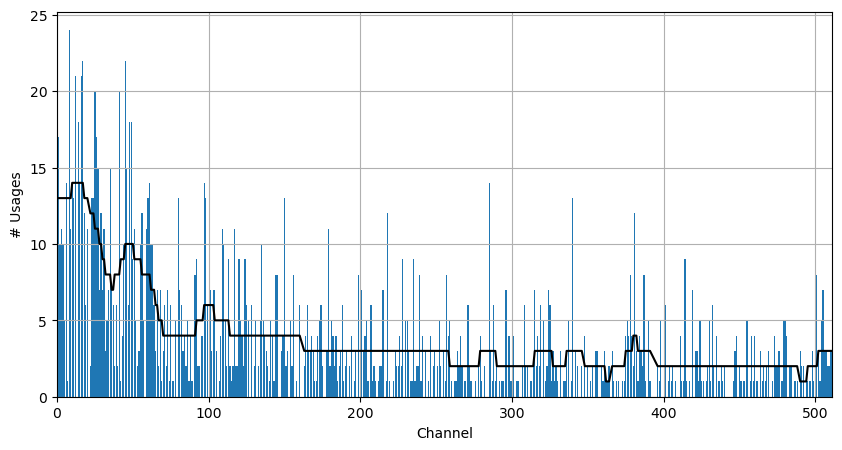

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
grouped = df[1].groupby("channel").size().reset_index(name="count")
grouped["channel"] = grouped["channel"].astype(int)
grouped = grouped.sort_values("channel")
ax.bar(grouped["channel"], grouped["count"])

smoothed = gaussian_filter1d(grouped["count"], sigma=5)
ax.plot(grouped["channel"], smoothed, color="black")

ax.set_xlabel("Channel")
ax.set_ylabel("# Usages")
ax.set_xlim(0, grouped["channel"].max())
ax.grid(zorder=0)
plt.savefig("figures/RQ1/ch_used.pdf", bbox_inches="tight")
matplot2tikz.save("figures/RQ1/ch_used.tex")

### Check Runtime

In [14]:
data = []
for dir in [grad_dir, smoothgrad_dir, occlusion_dir]:
    runt = []
    for data_file in glob(dir + "/**/*.txt"):
        with open(data_file, "r") as f:
            value = float(f.read().strip())
        runt.append(value)
    data.append(runt)

mean: 5.486, std: 0.294
mean: 5.838, std: 0.290
mean: 139.530, std: 1.164


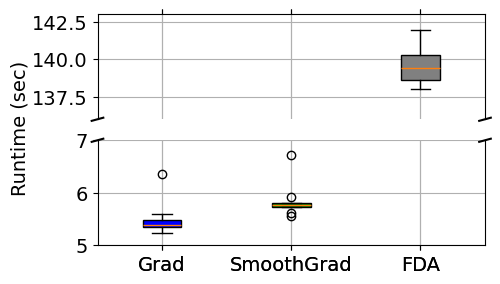

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(5, 3), sharex=True)
for a in ax:
    bplot = a.boxplot(data, tick_labels=["Grad", "SmoothGrad", "FDA"], patch_artist=True)
    a.grid()

    for patch, color in zip(bplot["boxes"], ["blue", "green", "grey"]):
        patch.set_facecolor(color)

ax[0].set_ylim(136, 143)  # zoomed-in top part
ax[1].set_ylim(5, 7)  # zoomed-in bottom part

ax[0].spines["bottom"].set_visible(False)
ax[1].spines["top"].set_visible(False)
ax[0].xaxis.tick_top()
ax[0].tick_params(labeltop=False)  # don't put labels at the top
ax[1].xaxis.tick_bottom()

# Add diagonal lines to indicate break
d = 0.015  # size of diagonal lines
kwargs = dict(transform=ax[0].transAxes, color="k", clip_on=False)
ax[0].plot((-d, +d), (-d, +d), **kwargs)  # top-left diagonal
ax[0].plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax[1].transAxes)
ax[1].plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax[1].plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

fig.text(-0.05, 0.5, "Runtime (sec)", va="center", rotation="vertical", fontsize=14)

plt.savefig("figures/RQ1/runt.pdf", bbox_inches="tight")
# matplot2tikz.save("figures/RQ1/runt.tex")
for d in data:
    print(f"mean: {np.mean(d):.3f}, std: {np.std(d):.3f}")

### Effect on Images

Mean: 0.077, std: 0.039
Mean: 0.076, std: 0.039
Mean: 0.062, std: 0.021


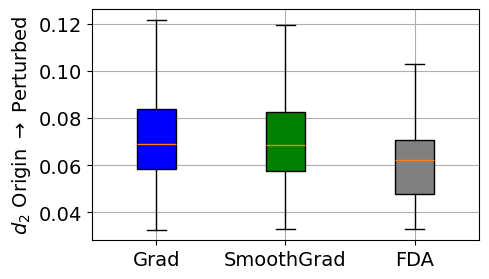

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
bplot = ax.boxplot(
    [d["image_change"] for d in df],
    tick_labels=["Grad", "SmoothGrad", "FDA"],
    patch_artist=True,
    showfliers=False,
)

for patch, color in zip(bplot["boxes"], ["blue", "green", "grey"]):
    patch.set_facecolor(color)

# ax.set_yscale("symlog", linthresh=1)
ax.set_ylabel(r"$d_2$ Origin $\rightarrow$ Perturbed")
ax.grid()
plt.savefig("figures/RQ1/im_ch.pdf", bbox_inches="tight")
matplot2tikz.save("figures/RQ1/im_ch.tex")
for d in [d["image_change"] for d in df]:
    print(f"Mean: {d.mean():.3f}, std: {d.std():.3f}")

/tmp/ipykernel_1646437/540778927.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


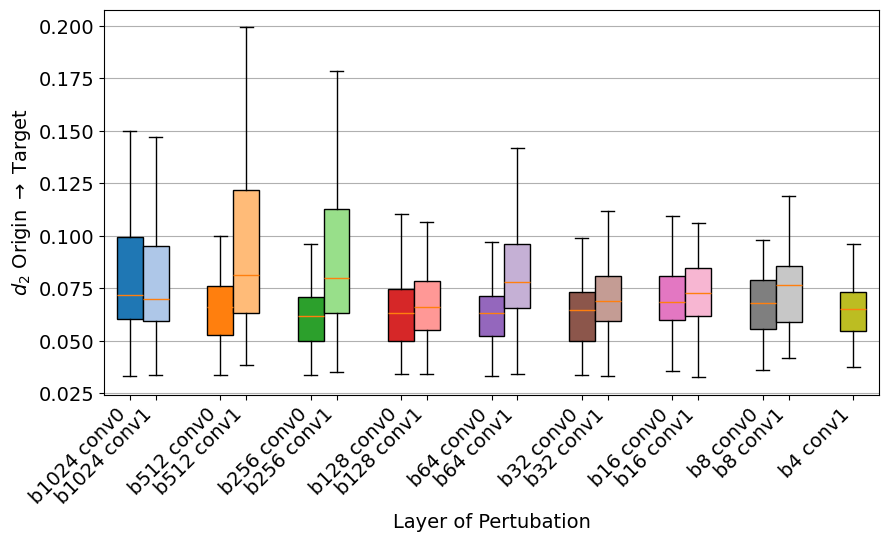

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
boxps = []
ticks = []
for layer, grouped in df[1].groupby("layer_name"):
    boxps.append(grouped["image_change"])
    ticks.append(" ".join(layer.split(".")[:2]))
# Here we sort based on layer-scale
boxps, ticks, _ = zip(
    *sorted(
        zip(boxps, ticks, [int(t.split(" ")[0][1:]) for t in ticks]),
        key=lambda x: x[2],
        reverse=True,
    )
)

positions = [0]
prev_tick = None
for i, tick in enumerate(ticks):
    if prev_tick is None:
        prev_tick = tick
    else:
        if prev_tick.split(" ")[0] == tick.split(" ")[0]:
            positions.append(positions[-1] + 0.5)
        else:
            positions.append(positions[-1] + 1.25)
        prev_tick = tick

bplot = ax.boxplot(
    boxps, positions=positions, tick_labels=ticks, patch_artist=True, showfliers=False
)

cmap = get_cmap("tab20")
for i, patch in enumerate(bplot["boxes"]):
    patch.set_facecolor(cmap(2 * (i // 2) + (i % 2)))

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
# ax[1].set_yscale("symlog", linthresh=1)
ax.set_xlabel("Layer of Pertubation")


ax.grid(axis="y")
ax.set_ylabel(r"$d_2$ Origin $\rightarrow$ Target")

plt.subplots_adjust(hspace=0.05)
plt.savefig("figures/RQ1/layers_im_ch.pdf", bbox_inches="tight")
# matplot2tikz.save("figures/RQ1/layers_im_ch.tex")

In [47]:
for d in [d["ssim"] for d in df]:
    print(f"Mean: {d.mean():.3f}, std: {d.std():.3f}")

Mean: 0.775, std: 0.067
Mean: 0.776, std: 0.067
Mean: 0.794, std: 0.060
